In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch09"

In [3]:
epoches, steps = [], []
train_losses, val_losses = [], []
learning_rates, created_at = [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    tag = f.name.replace("checkpoint_", "").replace(".json", "")
    epoches.append(int(tag.split("-", 1)[0]))
    steps.append(int(tag.split("-", 1)[-1]))
    train_losses.append(data['train_loss'])
    val_losses.append(data['val_loss'])
    learning_rates.append(data['learning_rate'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "epoch": epoches,
    "step": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "learning_rate": learning_rates,
    "created_at": created_at,
})


df = df.sort_values(by='step', ascending=True)

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

print(df.nsmallest(1, 'train_loss'))

#pd.concat((df.head(10), df.tail(10)))
df

    epoch    step  train_loss  val_loss  learning_rate              created_at
19      2  152000    1.687843  2.464561       0.000284  2025-09-16T02:23:20%:z


,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,8000,4.483925,4.491979,0.000038,2025-09-15T14:54:44%:z
1,1,16000,3.664065,3.767551,0.000076,2025-09-15T15:25:50%:z
2,1,24000,3.132821,3.307736,0.000114,2025-09-15T15:56:52%:z
3,1,32000,2.760071,2.984072,0.000152,2025-09-15T16:59:42%:z
4,1,40000,2.548054,2.810270,0.000191,2025-09-15T17:44:57%:z
5,1,48000,2.392028,2.710667,0.000229,2025-09-15T18:16:03%:z
6,1,56000,2.291321,2.651382,0.000267,2025-09-15T18:47:07%:z
7,1,64000,2.167756,2.592231,0.000300,2025-09-15T19:18:20%:z
8,1,72000,2.089280,2.563814,0.000300,2025-09-15T19:49:36%:z
9,1,80000,2.011697,2.533019,0.000299,2025-09-15T20:27:55%:z


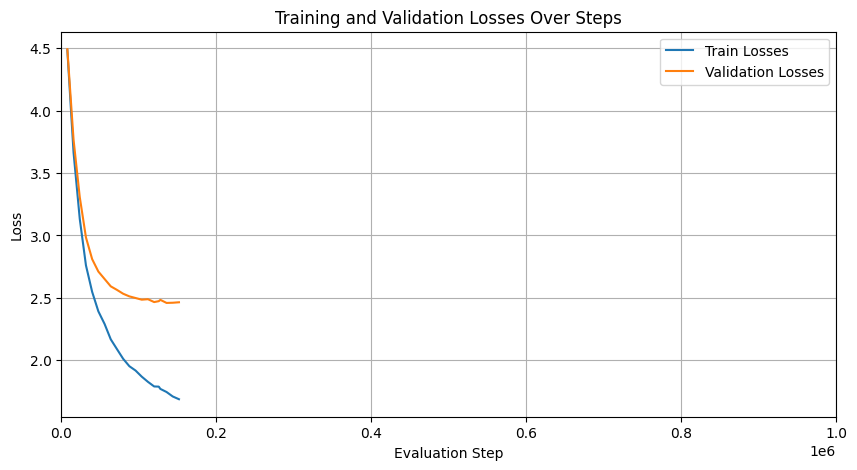

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Losses")
plt.plot(df['step'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.xlim(0, max(1e6, df["step"].max()))

plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

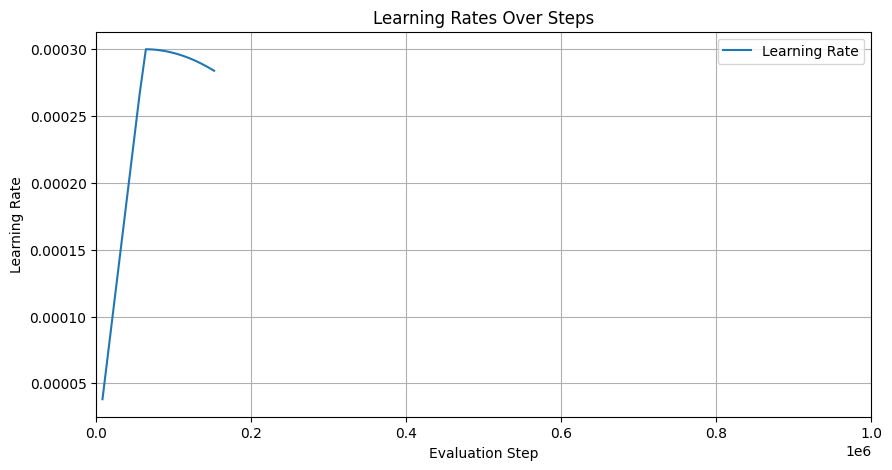

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")